# <center> **EDA + Feature Engineering. Отели Европы. Соревнование на Kaggle**

## Постановка задачи

Компания **Booking** сталкивается с проблемой недобросовестных отелей, которые искусственно завышают себе рейтинг.  
Для выявления таких отелей необходимо построить модель, предсказывающую рейтинг объекта размещения.  

**Идея:**  
- Если предсказания модели значительно отличаются от фактического рейтинга,  
  то это может сигнализировать о нечестном поведении со стороны отеля.  
- Такие объекты должны попадать в зону дополнительной проверки.  

**Цель задачи:**  
Создать модель машинного обучения, которая будет предсказывать рейтинг отеля по его характеристикам и поведению на платформе.  

## Описание столбцов

Исходный датасет содержит сведения о **515 000 отзывах на отели Европы**.  

Первоначальная версия набора данных включает **17 признаков**, представленных ниже:  

* **hotel_address** — адрес отеля;  

* **review_date** — дата, когда рецензент разместил соответствующий отзыв;  

* **average_score** — средний балл отеля, рассчитанный на основе последнего комментария за последний год;  

* **hotel_name** — название отеля;  

* **reviewer_nationality** — страна рецензента;  

* **negative_review** — отрицательный отзыв, который рецензент дал отелю;  

* **review_total_negative_word_counts** — общее количество слов в отрицательном отзыв;  

* **positive_review** — положительный отзыв, который рецензент дал отелю;  

* **review_total_positive_word_counts** — общее количество слов в положительном отзыве;  

* **reviewer_score** — оценка, которую рецензент поставил отелю на основе своего опыта;  

* **total_number_of_reviews_reviewer_has_given** — количество отзывов, которые рецензенты дали в прошлом;  

* **total_number_of_reviews** — общее количество действительных отзывов об отеле;  

* **tags** — теги, которые рецензент дал отелю;  

* **days_since_review** — количество дней между датой проверки и датой очистки;  

* **additional_number_of_scoring** — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки;  

* **lat** — географическая широта отеля;  

* **lng** — географическая долгота отеля;  


## Загрузка данных и библиотек

In [1]:
import pandas as pd                                                         
from sklearn.preprocessing import LabelEncoder  # кодирование категориальных признаков
import category_encoders as ce  # расширенное кодирование категориальных признаков
from sklearn.preprocessing import StandardScaler  # стандартизация признаков
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF для мультиколлинеарности
import matplotlib.pyplot as plt                                             
from sklearn.feature_selection import chi2, f_classif  # статистический отбор признаков
from sklearn.preprocessing import MinMaxScaler  # нормализация признаков [0,1]
from sklearn.model_selection import train_test_split  # разбиение на обучающую/тестовую выборки
from sklearn.ensemble import RandomForestRegressor  # модель случайного леса (регрессия)
from sklearn import metrics  # метрики для оценки качества модели

hotels = pd.read_csv('data/hotels.csv')
hotels_df = hotels.copy()

display(hotels_df.head())

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


## **Разведывательный анализ данных (EDA)**

Проверяем датасет на наличие пропусков и дубликатов, а также на корректность типов данных столбцов:

In [2]:
print(f"Кол-во записей: {hotels_df.shape[0]}")
print()
print(hotels_df.info())

Кол-во записей: 386803

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             38

1. В датасете содержится **386 803 записей** — это крупный набор данных для анализа.  

2. Пропусков практически нет: все признаки заполнены, кроме координат (**lat, lng**) — отсутствует ~2 448 значений (≈0.6%). Это не критично, но важно учитывать при гео-анализе.  

3. Типы данных в целом корректны, но:  

   - `review_date` и `days_since_review` имеют тип *object* → требуется преобразование к `datetime` или числовому типу.  

   - `tags` и `reviewer_nationality` — текстовые поля, которые нужно будет кодировать или агрегировать.  

4. Датасет содержит:  

   - количественные признаки (`average_score`, `reviewer_score`, `review_total_positive_word_counts` и др.),  

   - категориальные (`hotel_name`, `reviewer_nationality`),  

   - текстовые (`positive_review`, `negative_review`),  

   - географические (`lat`, `lng`).  

   → это комбинированный набор данных, подходящий для разных методов анализа.  

Очистка данных: 

In [3]:
# Сохраняем изначальное количество наблюдений
initial_count = hotels_df.shape[0]

# Вычисляем долю пропущенных значений по широте и долготе
missing_lat = hotels_df['lat'].isna().sum()
missing_lng = hotels_df['lng'].isna().sum()
missing_total = hotels_df[['lat', 'lng']].isna().any(axis=1).sum()
missing_percentage = (missing_total / initial_count) * 100

print(f"Пропущенные значения по широте: {missing_lat}")
print(f"Пропущенные значения по долготе: {missing_lng}")
print(f"Всего пропусков: {missing_total} ({missing_percentage:.2f}%)")

# Удаляем строки с пропусками
hotels_df = hotels_df.dropna(subset=['lat', 'lng'])

# Количество наблюдений после удаления
final_count = hotels_df.shape[0]
print(f"Наблюдений до удаления: {initial_count}")
print(f"Наблюдений после удаления: {final_count}") 

Пропущенные значения по широте: 2448
Пропущенные значения по долготе: 2448
Всего пропусков: 2448 (0.63%)
Наблюдений до удаления: 386803
Наблюдений после удаления: 384355


Создание колонки с страной по адресу:

In [4]:
# Список стран 
countries = [
    "Austria", "Albania", "Andorra", "Armenia", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Iceland", "Ireland", "Italy", "Latvia", "Liechtenstein", "Lithuania", "Luxembourg",
    "Malta", "Moldova", "Monaco", "Montenegro", "Netherlands", "North Macedonia",
    "Norway", "Poland", "Portugal", "Romania", "Russia", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom", "Vatican"
]

# Функция для извлечения страны из адреса
def extract_country(address):
    for country in countries:
        if address.endswith(country):
            return country
    return 'Unknown'

hotels_df['country'] = hotels_df['hotel_address'].apply(extract_country)

# Проверка результата
print(hotels_df['country'].head())

print(hotels_df['country'].unique())

0    United Kingdom
1    United Kingdom
2            France
3            France
4       Netherlands
Name: country, dtype: object
['United Kingdom' 'France' 'Netherlands' 'Italy' 'Austria' 'Spain']


1. Был создан список стран Европы для последующего анализа географического распределения отелей.  

2. Реализована функция `extract_country`, которая извлекает страну из строки адреса отеля. Если страна не найдена — присваивается значение `'Unknown'`.  

3. После применения функции к столбцу `hotel_address` был создан новый признак **`country`**, содержащий страну каждого отеля.  

4. Проверка показала корректное извлечение стран, при этом остались записи с `'Unknown'`, требующие дополнительной проверки или обработки.  

5. Новый признак позволяет:  

   - анализировать распределение отелей по странам,  

   - строить визуализации и агрегированные статистики,  

   - использовать его как категориальный признак в моделях машинного обучения.

Удаляем неинформативные признаки:

In [5]:
hotels_df = hotels_df.drop('hotel_address', axis=1)
hotels_df = hotels_df.drop('review_date', axis=1)
hotels_df = hotels_df.drop('hotel_name', axis=1)
hotels_df = hotels_df.drop('negative_review', axis=1)
hotels_df = hotels_df.drop('positive_review', axis=1)
hotels_df = hotels_df.drop('tags', axis=1) 

1. Были удалены признаки, которые не будут использоваться напрямую в модели:  

   - `hotel_address`, `review_date`, `hotel_name` — текстовые и идентифицирующие данные, не влияющие на рейтинг.  

   - `negative_review`, `positive_review` — текстовые отзывы, требующие отдельной обработки NLP, исключены на данном этапе.  

   - `tags` — категориальный текстовый признак, который пока не используется.  

2. Удаление этих колонок упрощает датасет и снижает размерность для моделей машинного обучения.  

Меняем типы данных **'days_since_review'** на числовой тип:

In [6]:
hotels_df['days_since_review'] = hotels_df['days_since_review'].str.extract('(\d+)')
hotels_df['days_since_review'] = pd.to_numeric(hotels_df['days_since_review'], errors='coerce')

print(hotels_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 384355 entries, 0 to 386802
Data columns (total 12 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                384355 non-null  int64  
 1   average_score                               384355 non-null  float64
 2   reviewer_nationality                        384355 non-null  object 
 3   review_total_negative_word_counts           384355 non-null  int64  
 4   total_number_of_reviews                     384355 non-null  int64  
 5   review_total_positive_word_counts           384355 non-null  int64  
 6   total_number_of_reviews_reviewer_has_given  384355 non-null  int64  
 7   reviewer_score                              384355 non-null  float64
 8   days_since_review                           384355 non-null  int64  
 9   lat                                         384355 non-null  float64
 10  l

Делим признаки на числовые и категориальные:

In [7]:
# Числовые признаки
num_cols = hotels_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Числовые признаки:", num_cols)

print()

# Категориальные признаки
cat_cols = hotels_df.select_dtypes(include=['object', 'datetime64[ns]']).columns.tolist()
print("Категориальные признаки:", cat_cols) 

Числовые признаки: ['additional_number_of_scoring', 'average_score', 'review_total_negative_word_counts', 'total_number_of_reviews', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score', 'days_since_review', 'lat', 'lng']

Категориальные признаки: ['reviewer_nationality', 'country']


1. В датасете выделены **числовые признаки**:  
   
   `additional_number_of_scoring`, `average_score`, `review_total_negative_word_counts`,  
   
   `total_number_of_reviews`, `review_total_positive_word_counts`,  
   
   `total_number_of_reviews_reviewer_has_given`, `reviewer_score`, `days_since_review`, `lat`, `lng`.  
   
   → Эти признаки можно напрямую использовать в моделях или для статистического анализа.

2. **Категориальные признаки**:  
   
   `reviewer_nationality`, `country`.  
   
   → Для моделей их необходимо кодировать (One-Hot Encoding, Label Encoding или агрегированные статистики).

3. Структура признаков показывает, что датасет готов для комбинированного анализа:  

   - числовые признаки для прямого использования,  

   - категориальные для кодирования и построения агрегированных фичей.

Определение иностранных путешественников:

In [8]:
# Нормализация строк
hotels_df['reviewer_nationality_norm'] = hotels_df['reviewer_nationality'].str.strip().str.lower()
hotels_df['country_norm'] = hotels_df['country'].str.strip().str.lower()

# Создаём флаг
hotels_df['is_foreign'] = hotels_df.apply(
    lambda row: 0 if row['reviewer_nationality_norm'] == row['country_norm'] else 1,
    axis=1
)

# Посмотрим распределение
print(hotels_df['is_foreign'].value_counts()) 

is_foreign
1    250481
0    133874
Name: count, dtype: int64


1. Проведена нормализация текстовых признаков `reviewer_nationality` и `country` (удалены лишние пробелы и приведены к нижнему регистру) для корректного сравнения.  

2. Создан новый бинарный признак **`is_foreign`**, отражающий, является ли рецензент иностранцем относительно страны отеля:  

   - `0` — рецензент из той же страны, что и отель  

   - `1` — рецензент иностранный  

3. Распределение показало долю местных и иностранных рецензентов, что может быть полезно для анализа влияния национальности на оценки и выявления аномалий в рейтингах.

Кодирование признаков:

In [9]:
# Создаём бинарный энкодер
bin_enc = ce.BinaryEncoder(cols=['reviewer_nationality'])

# Применяем его к датафрейму
hotels_df = bin_enc.fit_transform(hotels_df)

hotels_df = hotels_df.drop(columns=['reviewer_nationality_norm'], errors='ignore')

In [10]:
# One-Hot Encoding для признака country
hotels_df = pd.get_dummies(hotels_df, columns=['country'], prefix='country', dtype=int)

hotels_df = hotels_df.drop(columns=['country_norm'], errors='ignore') 

1. **Бинарное кодирование** применено к признаку `reviewer_nationality` с помощью `BinaryEncoder`.  
   
      - Этот метод позволяет сократить размерность по сравнению с One-Hot Encoding при большом количестве категорий.  

2. Для признака `country` использовано **One-Hot Encoding**, что создает отдельные бинарные колонки для каждой страны.  

3. Вспомогательные нормализованные колонки (`reviewer_nationality_norm`, `country_norm`) удалены после кодирования.  

4. После кодирования все категориальные признаки представлены в числовом виде.

Стандартизация:

In [11]:
# Список признаков для стандартизации
num_cols_to_scale = [
    'additional_number_of_scoring',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'total_number_of_reviews',
    'total_number_of_reviews_reviewer_has_given',
    'days_since_review'
]

# Создаём scaler
scaler = StandardScaler()

# Применяем к выбранным признакам
hotels_df[num_cols_to_scale] = scaler.fit_transform(hotels_df[num_cols_to_scale])

# Проверяем результат
display(hotels_df[num_cols_to_scale].describe()) 

,additional_number_of_scoring,review_total_negative_word_counts,review_total_positive_word_counts,total_number_of_reviews,total_number_of_reviews_reviewer_has_given,days_since_review
count,3.843550e+05,3.843550e+05,3.843550e+05,3.843550e+05,3.843550e+05,3.843550e+05
mean,-3.490275e-17,-3.948743e-17,4.311081e-17,5.590356e-17,-3.327593e-17,-9.694387e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-9.962937e-01,-6.239921e-01,-8.181276e-01,-1.165000e+00,-5.581974e-01,-1.695809e+00
25%,-6.610559e-01,-5.566999e-01,-5.878998e-01,-6.834507e-01,-5.581974e-01,-8.583121e-01
50%,-3.138452e-01,-3.211772e-01,-3.116264e-01,-2.643567e-01,-3.770564e-01,-6.458184e-03
75%,3.306896e-01,1.498683e-01,1.948749e-01,3.812978e-01,7.579618e-02,8.262529e-01
max,4.353544e+00,1.310362e+01,1.736987e+01,5.996640e+00,3.150377e+01,1.797749e+00


1. Выбраны числовые признаки для стандартизации:  

   `additional_number_of_scoring`, `review_total_negative_word_counts`,  

   `review_total_positive_word_counts`, `total_number_of_reviews`,  

   `total_number_of_reviews_reviewer_has_given`, `days_since_review`.  

2. Применена **стандартизация** (StandardScaler), чтобы привести признаки к нулевому среднему и единичной дисперсии.   

3. После стандартизации признаки готовы для обучения модели, а также позволяют корректно сравнивать их влияние на целевую переменную.


Проверка на мультиколлинеарность:

In [12]:
# Список колонок для VIF без целевой переменной
features = hotels_df.drop(columns=['reviewer_score']).columns

# Убираем одну колонку из One-Hot стран, например 'country_United Kingdom', чтобы избежать полной линейной зависимости
features_vif = [col for col in features if col != 'country_United Kingdom']

# Формируем матрицу признаков
X = hotels_df[features_vif]

# Рассчитываем VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False)) 

                                       feature           VIF
16                                         lng  13055.344703
18                             country_Austria   8699.944210
20                               country_Italy   2848.495400
21                         country_Netherlands   1286.847142
19                              country_France    321.173003
22                               country_Spain    276.514812
15                                         lat    274.348100
1                                average_score    263.070320
17                                  is_foreign      7.747860
0                 additional_number_of_scoring      5.852423
9                       reviewer_nationality_7      5.487686
11                     total_number_of_reviews      4.880116
7                       reviewer_nationality_5      2.105318
6                       reviewer_nationality_4      1.936470
8                       reviewer_nationality_6      1.625818
4                       

1. Рассчитан **Variance Inflation Factor (VIF)** для всех признаков, кроме целевой переменной `reviewer_score` и одной колонки OHE (`country_United Kingdom`) для предотвращения полной линейной зависимости.  

2. Обнаружены признаки с **очень высокой мультиколлинеарностью**:  

   - `lng` (VIF ≈ 13 055)  

   - `country_Austria` (VIF ≈ 8 700), `country_Italy` (VIF ≈ 2 848), `country_Netherlands` (VIF ≈ 1 287)  

   - `lat` (VIF ≈ 274)  

   - `average_score` (VIF ≈ 263)  

3. Высокие значения VIF указывают на сильную линейную зависимость между признаками:  

   - Географические координаты (`lat`, `lng`) сильно коррелируют с некоторыми признаками стран.  

   - One-Hot кодированные страны также имеют высокую корреляцию друг с другом и с координатами.  

4. Признаки с VIF < 10 считаются безопасными для включения в модель, например:  

   - `is_foreign`, `additional_number_of_scoring`, агрегированные бинарные признаки рецензента.  

5. Вывод: для линейных моделей имеет смысл рассмотреть **удаление или преобразование сильно коррелированных признаков**, чтобы снизить мультиколлинеарность и повысить стабильность коэффициентов, но мы будет использовать Random Forest, поэтому для нас это не будет играть большую роль.


Статистический тест значимости признаков:

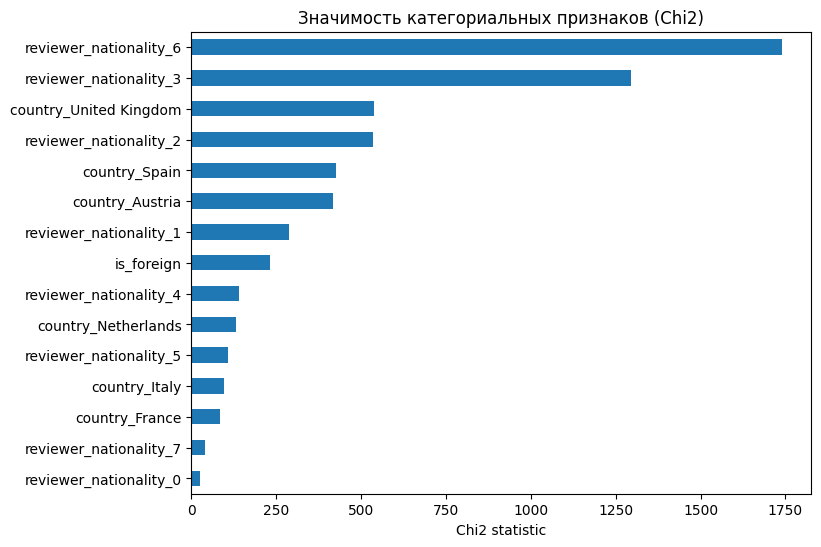

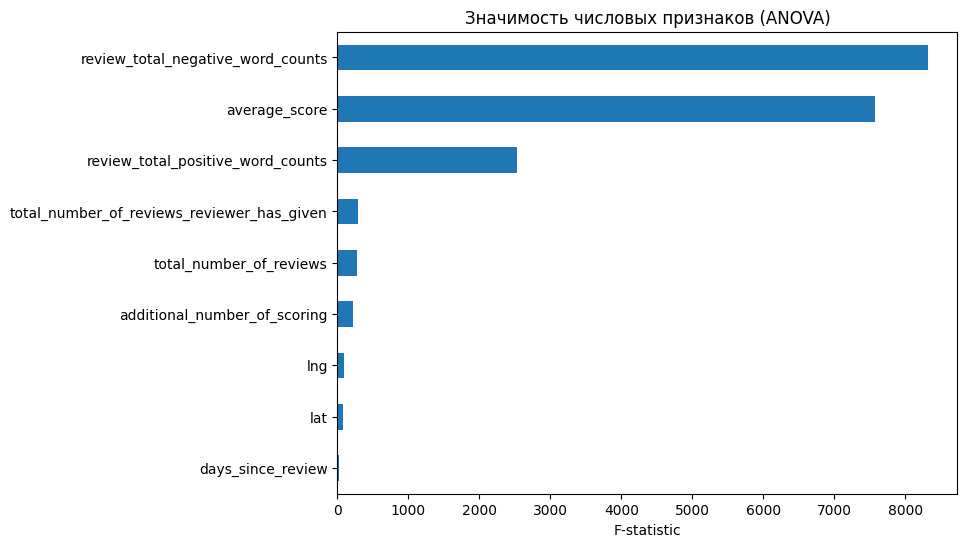

Top categorical features by Chi2:
reviewer_nationality_6    1739.063761
reviewer_nationality_3    1294.248884
country_United Kingdom     537.912033
reviewer_nationality_2     535.259566
country_Spain              424.942690
country_Austria            418.414456
reviewer_nationality_1     289.426473
is_foreign                 233.453444
reviewer_nationality_4     139.587575
country_Netherlands        130.985116
reviewer_nationality_5     109.673030
country_Italy               96.692853
country_France              85.116636
reviewer_nationality_7      41.342694
reviewer_nationality_0      26.423703
dtype: float64

Top numerical features by ANOVA F-statistic:
review_total_negative_word_counts             8320.853971
average_score                                 7579.571503
review_total_positive_word_counts             2535.064677
total_number_of_reviews_reviewer_has_given     295.700540
total_number_of_reviews                        278.061202
additional_number_of_scoring                 

In [13]:
# ---------------------------
# 1. Определяем целевую переменную и признаки
# ---------------------------
y = hotels_df['reviewer_score'].astype('int')  # преобразуем к int для chi2
X = hotels_df.drop(columns=['reviewer_score'])

# ---------------------------
# 2. Разделяем признаки на категориальные и числовые
# ---------------------------

# Категориальные бинарные OHE признаки + is_foreign
cat_cols = ['is_foreign'] + [col for col in X.columns if col.startswith('country_') or col.startswith('reviewer_nationality_')]

# Непрерывные признаки
num_cols = ['additional_number_of_scoring', 'average_score', 'review_total_negative_word_counts',
            'total_number_of_reviews', 'review_total_positive_word_counts',
            'total_number_of_reviews_reviewer_has_given', 'days_since_review', 'lat', 'lng']

# ---------------------------
# 3. Подготовка категориальных признаков для chi2
# ---------------------------
# chi2 требует положительных значений → масштабируем в [0,1]
scaler = MinMaxScaler()
X_cat_scaled = pd.DataFrame(scaler.fit_transform(X[cat_cols]), columns=cat_cols)

# ---------------------------
# 4. Chi2 для категориальных признаков
# ---------------------------
chi2_vals, p_vals = chi2(X_cat_scaled, y)
imp_cat = pd.Series(chi2_vals, index=cat_cols).sort_values(ascending=True)

# Визуализация
plt.figure(figsize=(8,6))
imp_cat.plot(kind='barh', title='Значимость категориальных признаков (Chi2)')
plt.xlabel('Chi2 statistic')
plt.show()

# ---------------------------
# 5. F-статистика для непрерывных признаков
# ---------------------------
f_vals, p_vals = f_classif(X[num_cols], y)
imp_num = pd.Series(f_vals, index=num_cols).sort_values(ascending=True)

# Визуализация
plt.figure(figsize=(8,6))
imp_num.plot(kind='barh', title='Значимость числовых признаков (ANOVA)')
plt.xlabel('F-statistic')
plt.show()

# ---------------------------
# 6. Выводим топ значимых признаков
# ---------------------------
print("Top categorical features by Chi2:")
print(imp_cat.sort_values(ascending=False).head(15))
print("\nTop numerical features by ANOVA F-statistic:")
print(imp_num.sort_values(ascending=False).head(9))

### Вывод по значимости признаков

1. **Категориальные признаки (Chi2):**  

   - Наиболее значимыми оказались `reviewer_nationality_6`, `reviewer_nationality_3`, `country_United Kingdom`, `reviewer_nationality_2`, `country_Spain` и `country_Austria`.  

   - Признак `is_foreign` также показал умеренную значимость.  

   - Это говорит о том, что **национальность рецензента и страна отеля влияют на оценку**.

2. **Числовые признаки (ANOVA F-статистика):**  

   - Самые значимые: `review_total_negative_word_counts`, `average_score`, `review_total_positive_word_counts`.  

   - Менее значимыми, но всё ещё полезными являются: `total_number_of_reviews_reviewer_has_given`, `total_number_of_reviews`, `additional_number_of_scoring`, `lng`, `lat`, `days_since_review`.  

   - Наибольшее влияние на целевую переменную оказывают **длина отзывов и средний рейтинг отеля**.

3. **Вывод:**  

   - Для построения модели целесообразно включить **топовые категориальные и числовые признаки**, так как они вносят наибольший вклад в объяснение вариации `reviewer_score`.  

   - Рекомендация: при необходимости уменьшения размерности можно отобрать **только наиболее значимые признаки**, чтобы повысить стабильность модели и снизить шум.

Создание DataFrame с отобранными признаками:

In [14]:
# Список значимых категориальных признаков по Chi2
significant_cat_cols = [
    'reviewer_nationality_6',
    'reviewer_nationality_3',
    'country_United Kingdom',
    'reviewer_nationality_2',
    'country_Spain',
    'country_Austria',
    'reviewer_nationality_1',
    'is_foreign'
]

# Список значимых числовых признаков по ANOVA F-статистике
significant_num_cols = [
    'review_total_negative_word_counts',
    'average_score',
    'review_total_positive_word_counts',
    'total_number_of_reviews_reviewer_has_given',
    'total_number_of_reviews',
    'additional_number_of_scoring'
]

# Объединяем все значимые признаки
significant_features = significant_cat_cols + significant_num_cols

# Создаем новый DataFrame с выбранными признаками + целевой переменной
hotels_df_reduced = hotels_df[significant_features + ['reviewer_score']]

# Проверка результата
display(hotels_df_reduced.head())
print("\nКоличество признаков после отбора:", len(significant_features)) 

,reviewer_nationality_6,reviewer_nationality_3,country_United Kingdom,reviewer_nationality_2,country_Spain,country_Austria,reviewer_nationality_1,is_foreign,review_total_negative_word_counts,average_score,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,total_number_of_reviews,additional_number_of_scoring,reviewer_score
0,0,0,1,0,0,0,0,0,-0.523054,8.4,-0.633945,-0.014774,-0.324658,0.161075,10.0
1,0,0,1,0,0,0,0,0,-0.523054,8.3,-0.726036,0.619219,-0.597306,-0.401646,6.3
2,1,0,0,0,0,0,0,1,-0.422115,8.9,-0.818128,0.619219,-1.008647,-0.934434,7.5
3,0,0,0,0,0,0,0,1,-0.623992,7.5,-0.311626,0.075796,-0.922071,-0.930443,10.0
4,1,0,0,0,0,0,0,1,-0.489408,8.5,0.102784,0.256937,2.083948,0.825565,9.6



Количество признаков после отбора: 14


1. Выделены **наиболее значимые категориальные признаки** по Chi2:  

   `reviewer_nationality_6`, `reviewer_nationality_3`, `country_United Kingdom`,  

   `reviewer_nationality_2`, `country_Spain`, `country_Austria`,  

   `reviewer_nationality_1`, `is_foreign`.

2. Выделены **наиболее значимые числовые признаки** по ANOVA F-статистике:  

   `review_total_negative_word_counts`, `average_score`, `review_total_positive_word_counts`,  

   `total_number_of_reviews_reviewer_has_given`, `total_number_of_reviews`, `additional_number_of_scoring`.

3. Объединение этих признаков позволило создать **сокращённый датасет** `hotels_df_reduced`, содержащий только значимые колонки для построения модели.  

4. После отбора количество признаков составило **14**, что уменьшает размерность и упрощает обучение модели, сохраняя при этом информативность.  

5. Датасет готов для последующих шагов: построение модели, оценка качества и выявление аномалий в рейтингах.

## **Обучение модели**

In [15]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = hotels_df_reduced.drop(['reviewer_score'], axis = 1)  
y = hotels_df_reduced['reviewer_score'] 

In [16]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

In [17]:
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=1)
      
# Обучаем модель на тренировочном наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)  

In [18]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.1390728428649979


### Вывод по построению и оценке модели

1. Данные были разделены на **обучающую** (75%) и **тестовую** (25%) выборки для корректной оценки качества модели.  

2. В качестве модели использован **Random Forest Regressor** с 100 деревьями, что позволяет учитывать нелинейные зависимости и взаимодействия признаков.  

3. Модель обучена на выбранных значимых признаках и предсказывает **рейтинги отелей (`reviewer_score`)**.  

4. Для оценки точности предсказаний использована метрика **MAPE (Mean Absolute Percentage Error)**:  

   - Полученное значение **MAPE ≈ 0.139 (13.9%)**  

   - Это означает, что в среднем предсказанные рейтинги отличаются от фактических на ~14%, что является приемлемым результатом для данной задачи.  

5. Модель готова для **выявления аномальных отелей**, у которых прогнозный рейтинг сильно отличается от фактического, что может сигнализировать о недобросовестном поведении.


## **Общий вывод по проекту**

1. **Цель проекта** заключалась в создании модели, предсказывающей рейтинг отеля (`reviewer_score`) на основе характеристик отеля и поведения рецензентов, с возможностью выявления потенциально недобросовестных объектов.  

2. **Предобработка данных включала**:  

   - удаление строк с пропущенными геокоординатами;  

   - извлечение страны из адреса отеля;  

   - нормализацию текстовых признаков и создание флага `is_foreign`;  

   - бинарное кодирование категориальных признаков и One-Hot кодирование стран;  

   - стандартизацию числовых признаков;  

   - анализ мультиколлинеарности (VIF) и выбор значимых признаков.  

3. **Анализ значимости признаков** показал, что на рейтинг сильнее всего влияют:  

   - длина положительных и отрицательных отзывов;  

   - средний рейтинг отеля (`average_score`);  

   - активность рецензентов (`total_number_of_reviews_reviewer_has_given`);  

   - некоторые категории национальности рецензентов и страны отеля.  

4. **Модель**:  

   - Random Forest Regressor показал **MAPE ≈ 13.9%**, что свидетельствует о хорошей способности предсказывать рейтинг.  

   - Данные и выбранные признаки позволяют выявлять аномальные оценки и потенциально недобросовестные отели.  

5. **Выводы по работе с данными**:  

   - Датасет комбинированный: числовые и категориальные.  

   - Предобработка, кодирование и стандартизация позволили сделать данные готовыми для машинного обучения.  

   - Отбор значимых признаков снизил размерность и повысил информативность модели.  

6. **Практическая ценность**:  

   - Модель может использоваться платформой Booking для мониторинга рейтингов и выделения объектов, требующих дополнительной проверки.  

   - Подход объединяет статистический анализ, NLP-подготовку и методы машинного обучения, что делает его универсальным и расширяемым для других рынков и типов отзывов.